In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
plt.rc("xtick", labelsize = 15, top = False, bottom = False, direction = "in")   
plt.rc("ytick", labelsize = 15, left = False, right = False, direction = "in")
plt.rc("axes", grid = False, linewidth = 1.2, axisbelow = True)
plt.rc("grid", ls = "dotted", lw = 1)     
plt.rc("font", size = 30, family = "serif", serif = ["Computer Modern Serif"])
plt.rc("text", usetex = True)
plt.rc("figure", figsize = (12, 6), dpi = 72)
plt.rc("ytick.major", width = 1)
plt.rc("xtick.major", width = 1)
plt.rc("legend", fontsize = 15, framealpha = 0.5, edgecolor = "black", fancybox = True)

In [17]:
def pointFinder(y, t, ofs=0, err=0.1):
    # Centrer signalet omkring 0 for nemmere beregning
    y_centered = y - ofs
    
    # Find alle steder hvor signalet skifter fortegn
    sign_changes = np.where(np.diff(np.sign(y_centered)) != 0)[0]
    
    intersects = []
    t1 = []
    
    if len(sign_changes) > 0:
        intersects.append(sign_changes[0])
        t1.append(t[sign_changes[0]])
        
        for idx in sign_changes[1:]:
            if idx - intersects[-1] > 10: 
                intersects.append(idx)
                t1.append(t[idx])

    tops = []
    t2 = []
    for i in range(1, len(intersects)):
        start, end = intersects[i-1], intersects[i]
        interval_y = y[start:end]
        interval_t = t[start:end]
        
        if len(interval_y) == 0: 
            continue

        # Afgør om intervallet er en top eller en dal
        if np.mean(interval_y) > ofs:
            extreme_val = np.max(interval_y)
            # Find alle indekser, der har denne max-værdi
            all_indices = np.where(interval_y == extreme_val)[0]
        else:
            extreme_val = np.min(interval_y)
            # Find alle indekser, der har denne min-værdi
            all_indices = np.where(interval_y == extreme_val)[0]
            
        # Vælg det midterste indeks af plateauet (heltalsdivision giver midten)
        idx = all_indices[len(all_indices) // 2]
            
        tops.append(interval_y[idx])
        t2.append(interval_t[idx])

    intersects = np.array(intersects)
    t1 = np.array(t1)
    tops = np.array(tops)
    t2 = np.array(t2)
    
    dy = err
    maske = (((tops) > (ofs + dy)) | ((tops) < (ofs - dy)))
    
    return intersects, t1, tops[maske], t2[maske]

In [18]:
#Bølgelængde
l = 632.8e-9 #m

#Længde af rør
L = 6e-2 #m

#Atmosfærisk tryk defineres
p0 = 1 #atm
#Højden som målingerne er over men andre peaks er under 
peakheight = 5 #V

#Liste af n-værdier
ns = []

#Antal datasæt der skal gennemløbes
sets = 3

#Usikkerheder defineres
sigmaV = (4.92710400 - 4.83421500)/2 #V
sigmaL = 0.5e-3 #m
sigmap = 0.05 #atm

#Ophobningsloven som funktion defineres
sigmaChi = lambda V, L, p: np.sqrt((L+p)**2*sigmaV**2 + (V+l+p)**2*sigmaL**2 + (V+L+l)**2 * sigmap**2)

for i in range(sets):
    #Datasæt indlæses
    data = np.loadtxt(f"../Data/Day 1/Pump-000{i+1}.txt", skiprows=3)

    #Tryk for sættet defineres
    p = 2 #atm

    #Sættet splittes op i tid og spænding
    time = data[:,0]
    voltage = data[:,1]

    #Funktion der finder peaks og valleys bruges
    _, _, tops, times = pointFinder(voltage, time, ofs=np.mean(voltage), err=0.8)

    #Antallet af peaks over den givne højde findes
    Omega = len(tops[tops > peakheight])

    #Chi findes
    chi = (Omega*l/L)/(p/p0 -1)

    #n findes
    n = 1+chi
    
    #Usikkerheden for Chi i datasættet findes
    sigma = sigmaChi(.001, .001, .001)

    #n og usikkerhed tilføjes til liste
    ns.append(np.array([n, sigma]))
ns = np.array(ns)

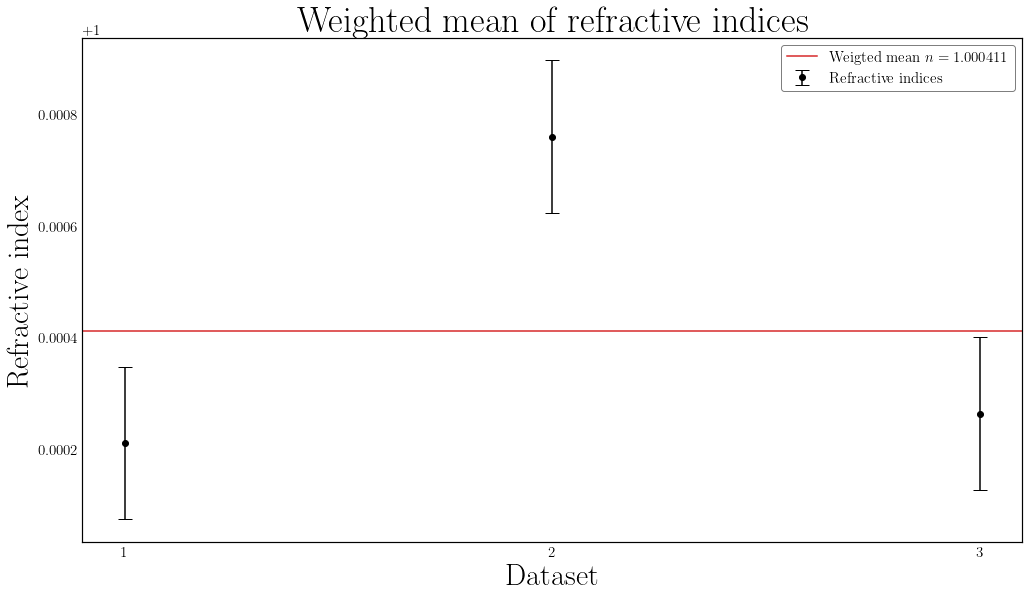

In [19]:
refIndecies = ns[:,0]
sigmas = ns[:,1]
navg = np.average(refIndecies, weights=1/sigmas**2)

fig, ax = plt.subplots(figsize=(15,9))

ax.errorbar(list(range(1, len(ns)+1)), refIndecies, fmt="o", color="black", yerr=sigmas, label="Refractive indices", capsize = 7)
ax.axhline(navg, color="C3", label=f"Weigted mean $n = {navg:.6f}$")
ax.set_xticks(list(range(1, len(ns)+1)))
ax.set_xlabel("Dataset")
ax.set_ylabel("Refractive index")
ax.set_title("Weighted mean of refractive indices")
ax.legend()

fig.tight_layout()
